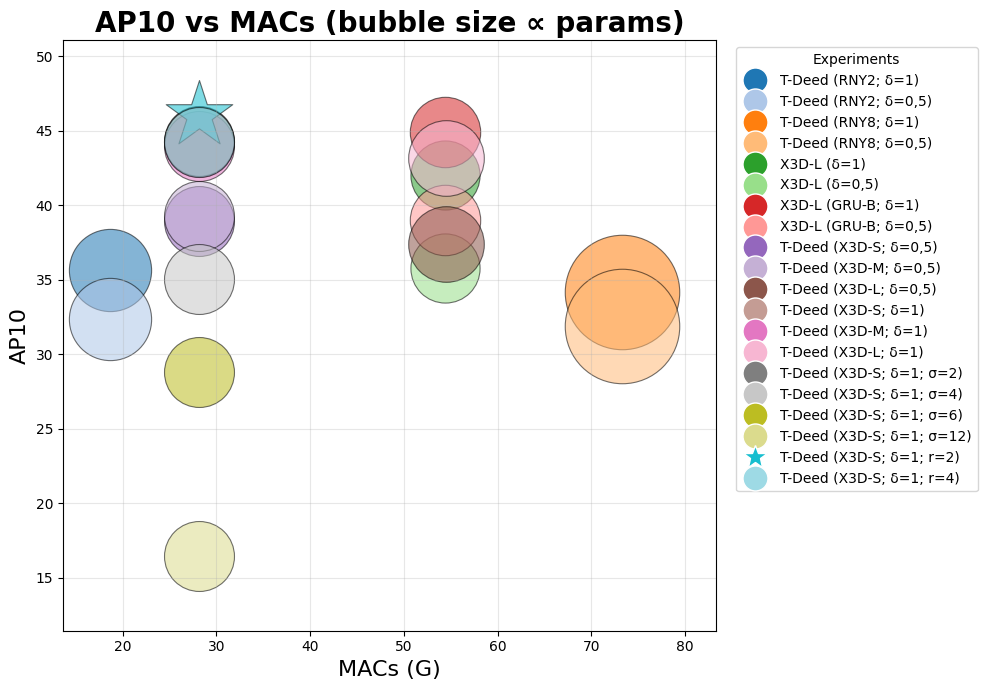

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Faltan por añadirse: 
url = "https://docs.google.com/spreadsheets/d/1sYY1RACchLtgORhuDemYNFv0M2VTN860rj6ic01Agns/export?format=csv"
df = pd.read_csv(url)
best_name = "T-Deed (X3D-S; δ=1; r=2)"

df_sel = df[
    df["Experiment"].notna() &
    (df["Experiment"].astype(str).str.strip() != "")
].copy().reset_index(drop=True)

# df_sel["exp_num"] = df_sel["Experiment"].str.extract(r'(\d+)').astype(int)
# df_sel = df_sel.sort_values("exp_num").reset_index(drop=True)

df_sel["id"] = range(1, len(df_sel) + 1)

df_sel["TOTAL PARAMS"] = (
    df_sel["TOTAL PARAMS"].astype(str).str.replace(",", "", regex=False)
)
df_sel["TOTAL PARAMS"] = pd.to_numeric(df_sel["TOTAL PARAMS"], errors="coerce")
df_sel["MACs"] = pd.to_numeric(df_sel["MACs"], errors="coerce")
df_sel["AP10"] = pd.to_numeric(df_sel["AP10"], errors="coerce")

sizes = np.sqrt(df_sel["TOTAL PARAMS"]) 

cmap = plt.get_cmap("tab20")
colors = [cmap(i%20) for i in range(len(df_sel))]

plt.figure(figsize=(10, 7))

handles = []
labels = []

for i, row in df_sel.iterrows():
    if row["Experiment"] == best_name:
        plt.scatter(
            row["MACs"],
            row["AP10"],
            s=sizes.iloc[i],
            alpha=0.55,
            color=colors[i],
            edgecolors="black",
            linewidths=0.8,
            marker="*"
        )
    else:
        plt.scatter(
            row["MACs"],
            row["AP10"],
            s=sizes.iloc[i],
            alpha=0.55,
            color=colors[i],
            edgecolors="black",
            linewidths=0.8
        )

plt.xlabel("MACs (G)", fontsize=16)
plt.ylabel("AP10", fontsize=16)
plt.title("AP10 vs MACs (bubble size ∝ params)", fontsize=20, fontweight='bold')

# plt.xlim(0, 100)
plt.xlim(min(df_sel["MACs"]) - 5, max(df_sel["MACs"]) + 10)
plt.ylim(min(df_sel["AP10"]) - 5, max(df_sel["AP10"]) + 5)

plt.grid(True, alpha=0.3)

legend_elements = []

for i, row in df_sel.iterrows():
    if row["Experiment"] == best_name:
        legend_elements.append(
            Line2D(
                [0], [0],
                marker='*',
                color='w',
                label=f'{row["Experiment"]}',
                markerfacecolor=colors[i],
                markersize=18
            )
        )
    else:
        legend_elements.append(
            Line2D(
                [0], [0],
                marker='o',
                color='w',
                label=f'{row["Experiment"]}',
                markerfacecolor=colors[i],
                markersize=18
            )
        )

plt.legend(
    handles=legend_elements,
    title="Experiments",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

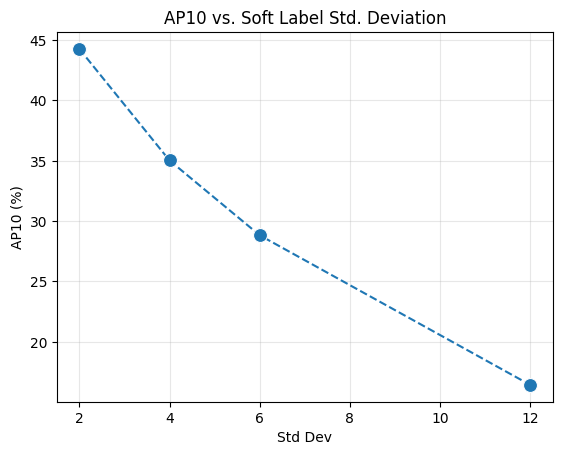

In [61]:
# Soft Label BarPlot
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

data = {"Std Dev": [2, 4, 6, 12], "AP10 (%)": [44.27, 35.03, 28.83, 16.43]}
data = pd.DataFrame.from_dict(data)

ax = sns.lineplot(data, x="Std Dev", y="AP10 (%)", marker="o", markersize=10)
ax.lines[0].set_linestyle('--')
plt.grid(True, alpha=0.3)
plt.title("AP10 vs. Soft Label Std. Deviation")
plt.show()